<h1 align="center">Assignment 3: Understanding Customer Tipping Behavior</h1>

### Dataset description

The dataset contains information about restaurant bills and tips. Each row represents one dining group.


- ```total_bill```: total cost of the meal
- ```tip```: tip amount
- ```sex```: gender of the person paying
- ```smoker```: whether the group included smokers
- ```day```: day of the weak
- ```time```: lunch or dinner
- ```size```: group size

### Imports

In [1]:
import pandas as pd
import seaborn as sns

## Q1. Loading and Understanding the Dataset

1. Load the ```tips``` dataset from seaborn

In [2]:
df = sns.load_dataset("tips")

2. Display the first 5 rows

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


3. Print:
   - Dataset shape
   - Column names

In [4]:
df.shape

(244, 7)

In [5]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [6]:
# checking types of columns and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## Q2. Basic Filtering - Who tips more?

1. Filter only weekend customers (Saturday & Sunday).

In [7]:
df["day"].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']

In [8]:
weekend = df[df["day"].isin(('Sat', 'Sun'))]

In [9]:
weekday = df[~df["day"].isin(('Sat', 'Sun'))]

2. Among them, find:
   - Average tip
   - Average total bill

In [10]:
# 2 - weekend
weekend_mean_tip = weekend["tip"].mean()
weekend_mean_tip

np.float64(3.115276073619632)

In [11]:
weekend_mean_total_bill = weekend["total_bill"].mean()
weekend_mean_total_bill

np.float64(20.893006134969326)

In [12]:
# 2 - weekday
weekday_mean_tip = weekday["tip"].mean()
weekday_mean_tip

np.float64(2.7628395061728392)

In [13]:
weekday_mean_total_bill = weekday["total_bill"].mean()
weekday_mean_total_bill

np.float64(17.55814814814815)

3. Compare this with weekday customers

**Weekend** customers leave more tips and their bills are higher.

In [14]:
# Tips difference
weekend_mean_tip - weekday_mean_tip

np.float64(0.35243656744679264)

In [15]:
# Total bills difference
weekend_mean_total_bill - weekday_mean_total_bill

np.float64(3.334857986821177)

## Q3. Sorting and Identifying High-Value Customers

1. Sort customers by ```total_bill``` (descending)

In [16]:
df_sorted = df.sort_values(by="total_bill", ascending=False)

In [17]:
df_sorted.head()

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3


2. Display the **top 10 highest bills**

In [18]:
df_sorted.iloc[:10]

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3
102,44.30,2.50,Female,Yes,Sat,Dinner,3
197,43.11,5.00,Female,Yes,Thur,Lunch,4
142,41.19,5.00,Male,No,Thur,Lunch,5
184,40.55,3.00,Male,Yes,Sun,Dinner,2
95,40.17,4.73,Male,Yes,Fri,Dinner,4


3. What do you nitice about their group sizes?

Groups sizes ```size``` of top 10 highest bills are all higher than 1, ranging from 2 to 6

## Q4. Data Quality Check & Cleaning

1. Check if the dataset has missing values 

In [19]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

2. Why **missing values are dangerous** in machine learning? 

Becaues they can break internal alghorithms, provide the bias in data, leading to false predicitions and underestimating features significance

## Q5. Visualization - What Influence Tips?

1. Plot
2. Interpret each plot in 1-2 sentences

- Tip vs Total Bill (scatter plot)

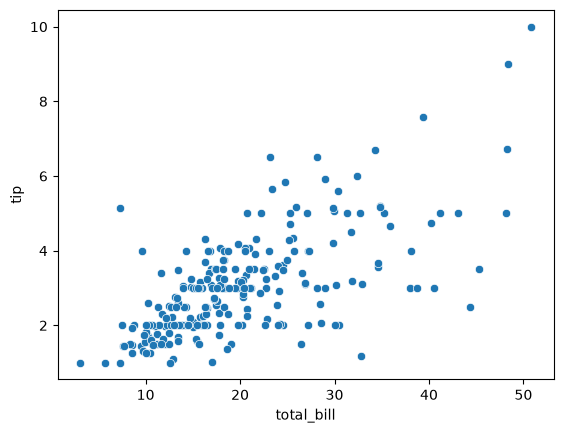

In [20]:
sns.scatterplot(data=df, x="total_bill", y="tip");

The scatterplot shows the relationship between total_bill and tip. From this scatterplot we can see the positive linear correlation between those 2 variables (tip is increasing with total_bill in a straight line)

- Average tip by day (bar plot) 

In [21]:
df.groupby(by="day")["tip"].mean()

day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64

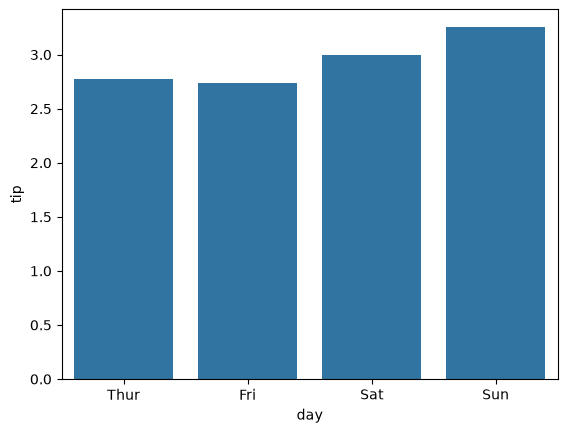

In [22]:
sns.barplot(data=df.groupby(by="day")["tip"].mean());

Barplot shows the data of average tip accross distinct categories, week days. Weekends have the highest average tip.

- Tip distribution (histogram)

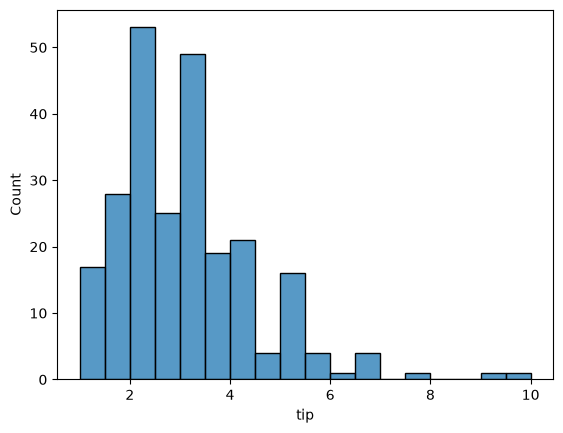

In [23]:
sns.histplot(data=df, x="tip", binwidth=0.5);

The histogram shows the distribution of all tips made, with single bin width of 0.5. Tips from 2 to 2.5 and from 3 to 3.5 are the most frequent.

## Q6. Final Insight & Conclusion 

- Who tips more?

In [24]:
df.groupby(by="sex")["tip"].mean()

sex
Male      3.089618
Female    2.833448
Name: tip, dtype: float64

In [25]:
df.groupby(by="smoker")["tip"].mean()

smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64

In [26]:
df.groupby(by="size")["tip"].mean()

size
1    1.437500
2    2.582308
3    3.393158
4    4.135405
5    4.028000
6    5.225000
Name: tip, dtype: float64

There were no question that could help answer if there is some group of people of specific gender or with smoking habits that tips more. Though I calculated average tips based on the ```sex```, ```smoker```, and ```size``` attributes.

There was no difference between smokers and non-smokers, but males tiped higher compared to demales and the larger the group size, the higher the tip. 

- When tips are highest?

1. The tips are highest on the weekends, Saturday and Sunday.
2. The higher the bill, the higher the tip.

- How this insight could help restaurant management?

Based on certain insights from the analysis, the restaurant management team can develop their plan of actions in order to increase the business income by preffering certain customers over others. Apart that, I don't see any usefull informration, that can help develop business. 